# 04. Visualisasi t-SNE dan Analisis Perbandingan

In [1]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [2]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_project_root():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FEATURES_DIR = RESULTS_DIR / "features"

for path in [DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, FEATURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST


In [3]:
CONFIG = {
    "random_seed": 42,
    "tsne_components": 2,
    "tsne_perplexity": 30,
    "tsne_max_iter": 1000,
}
random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

In [4]:
required_files = {
    "raw_features": FEATURES_DIR / "raw_features.npy",
    "labels": FEATURES_DIR / "labels.npy",
    "pca_features": FEATURES_DIR / "pca_features.npy",
    "autoencoder_latent_features": FEATURES_DIR / "autoencoder_latent_features.npy",
}
missing_files = [str(path) for path in required_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Beberapa file fitur belum ditemukan. Jalankan notebook 02 dan 03 terlebih dahulu. "
        f"File yang belum ada: {missing_files}"
    )
X_raw = np.load(required_files["raw_features"])
y_labels = np.load(required_files["labels"])
X_pca = np.load(required_files["pca_features"])
X_autoencoder = np.load(required_files["autoencoder_latent_features"])
print("Raw features         :", X_raw.shape)
print("PCA features         :", X_pca.shape)
print("Autoencoder features :", X_autoencoder.shape)
print("Labels               :", y_labels.shape)

Raw features         : (2000, 784)
PCA features         : (2000, 32)
Autoencoder features : (2000, 32)
Labels               : (2000,)


In [5]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def run_tsne(features, method_name):
    print(f"Menjalankan t-SNE untuk {method_name}...")
    start_time = time.time()
    try:
        tsne = TSNE(
            n_components=CONFIG["tsne_components"],
            perplexity=CONFIG["tsne_perplexity"],
            learning_rate="auto",
            init="pca",
            random_state=CONFIG["random_seed"],
            max_iter=CONFIG["tsne_max_iter"]
        )
        result = tsne.fit_transform(features)
    except TypeError:
        tsne = TSNE(
            n_components=CONFIG["tsne_components"],
            perplexity=CONFIG["tsne_perplexity"],
            learning_rate="auto",
            init="pca",
            random_state=CONFIG["random_seed"],
            n_iter=CONFIG["tsne_max_iter"]
        )
        result = tsne.fit_transform(features)
    elapsed = time.time() - start_time
    print(f"t-SNE {method_name} selesai dalam {elapsed:.2f} detik.")
    return result, elapsed

In [6]:
tsne_raw, time_raw = run_tsne(X_raw, "Raw Pixel")
tsne_pca, time_pca = run_tsne(X_pca, "PCA")
tsne_autoencoder, time_autoencoder = run_tsne(X_autoencoder, "Autoencoder")
np.save(FEATURES_DIR / "tsne_raw.npy", tsne_raw)
np.save(FEATURES_DIR / "tsne_pca.npy", tsne_pca)
np.save(FEATURES_DIR / "tsne_autoencoder.npy", tsne_autoencoder)

Menjalankan t-SNE untuk Raw Pixel...
t-SNE Raw Pixel selesai dalam 4.37 detik.
Menjalankan t-SNE untuk PCA...
t-SNE PCA selesai dalam 2.54 detik.
Menjalankan t-SNE untuk Autoencoder...
t-SNE Autoencoder selesai dalam 2.86 detik.


In [7]:
def calculate_silhouette(tsne_result, labels, method_name):
    try:
        score = silhouette_score(tsne_result, labels)
        print(f"Silhouette score {method_name}: {score:.6f}")
        return score
    except Exception as e:
        print(f"Gagal menghitung silhouette score untuk {method_name}: {e}")
        return np.nan

silhouette_raw = calculate_silhouette(tsne_raw, y_labels, "Raw Pixel + t-SNE")
silhouette_pca = calculate_silhouette(tsne_pca, y_labels, "PCA + t-SNE")
silhouette_autoencoder = calculate_silhouette(tsne_autoencoder, y_labels, "Autoencoder + t-SNE")

Silhouette score Raw Pixel + t-SNE: 0.143878
Silhouette score PCA + t-SNE: 0.152391
Silhouette score Autoencoder + t-SNE: 0.150130


In [8]:
tsne_metrics = pd.DataFrame([
    {"method": "Raw Pixel + t-SNE", "input_dim": X_raw.shape[1], "tsne_dim": 2, "silhouette_score": silhouette_raw, "tsne_time_seconds": time_raw},
    {"method": "PCA 32D + t-SNE", "input_dim": X_pca.shape[1], "tsne_dim": 2, "silhouette_score": silhouette_pca, "tsne_time_seconds": time_pca},
    {"method": "Autoencoder 32D + t-SNE", "input_dim": X_autoencoder.shape[1], "tsne_dim": 2, "silhouette_score": silhouette_autoencoder, "tsne_time_seconds": time_autoencoder},
])
tsne_metrics_path = RESULTS_DIR / "tsne_metrics.csv"
tsne_metrics.to_csv(tsne_metrics_path, index=False)
display(tsne_metrics)
print("Metrik t-SNE disimpan ke:", tsne_metrics_path)

,method,input_dim,tsne_dim,silhouette_score,tsne_time_seconds
0,Raw Pixel + t-SNE,784,2,0.143878,4.371086
1,PCA 32D + t-SNE,32,2,0.152391,2.544416
2,Autoencoder 32D + t-SNE,32,2,0.150130,2.859433


Metrik t-SNE disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\tsne_metrics.csv


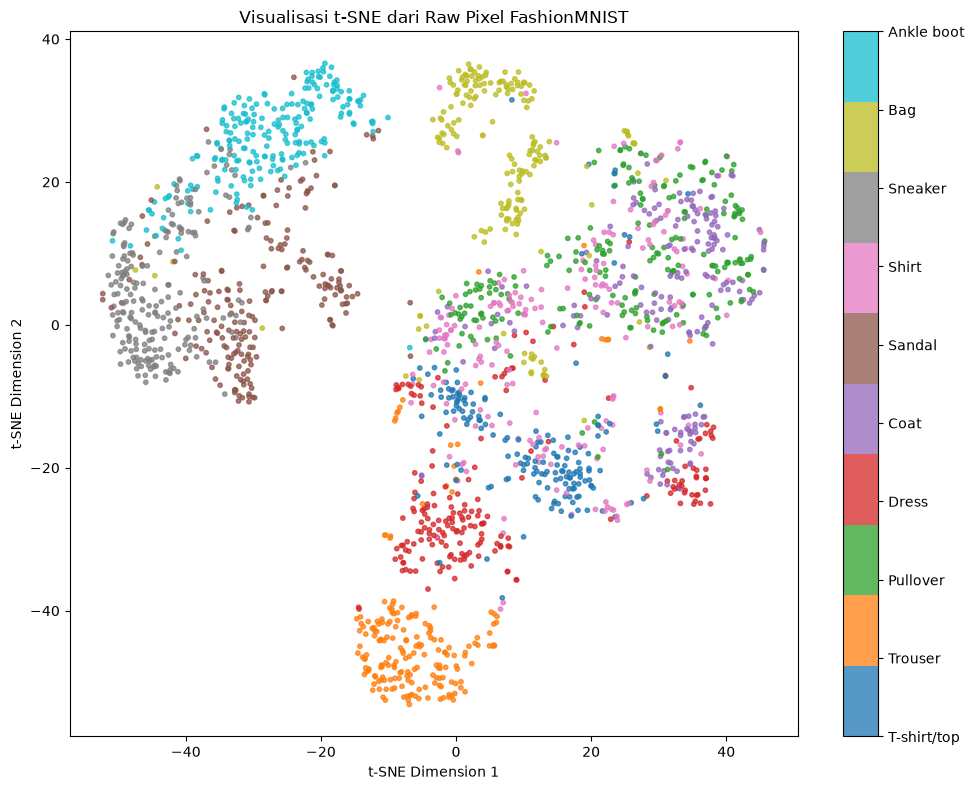

Gambar disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\tsne_raw_pixel.png


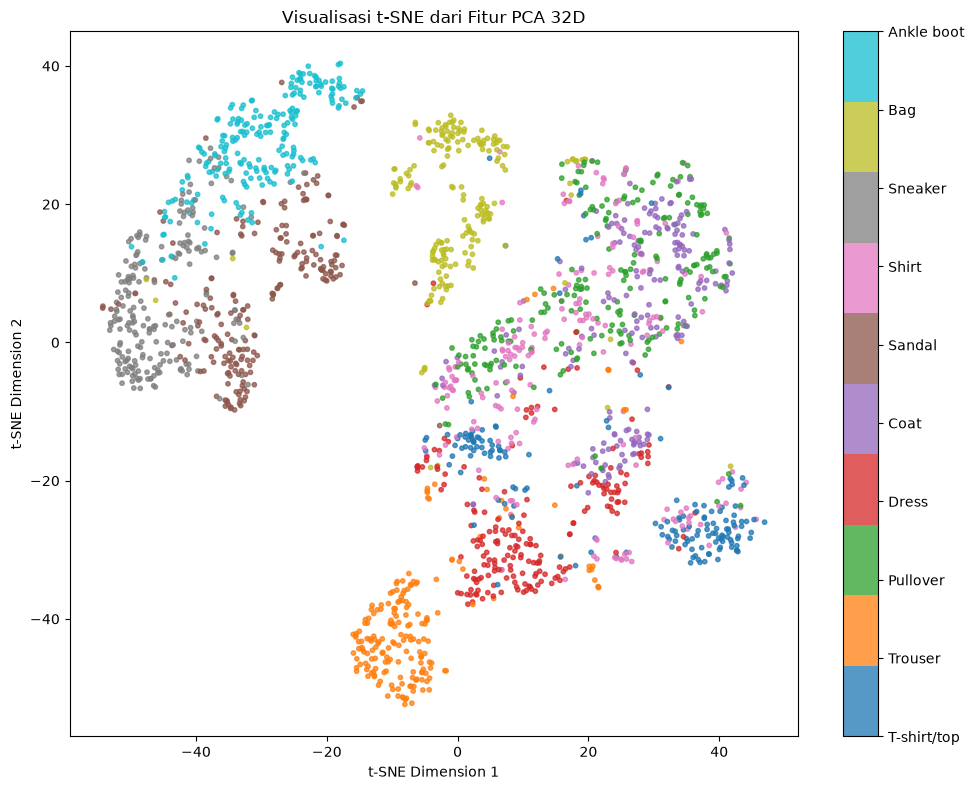

Gambar disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\tsne_pca_32d.png


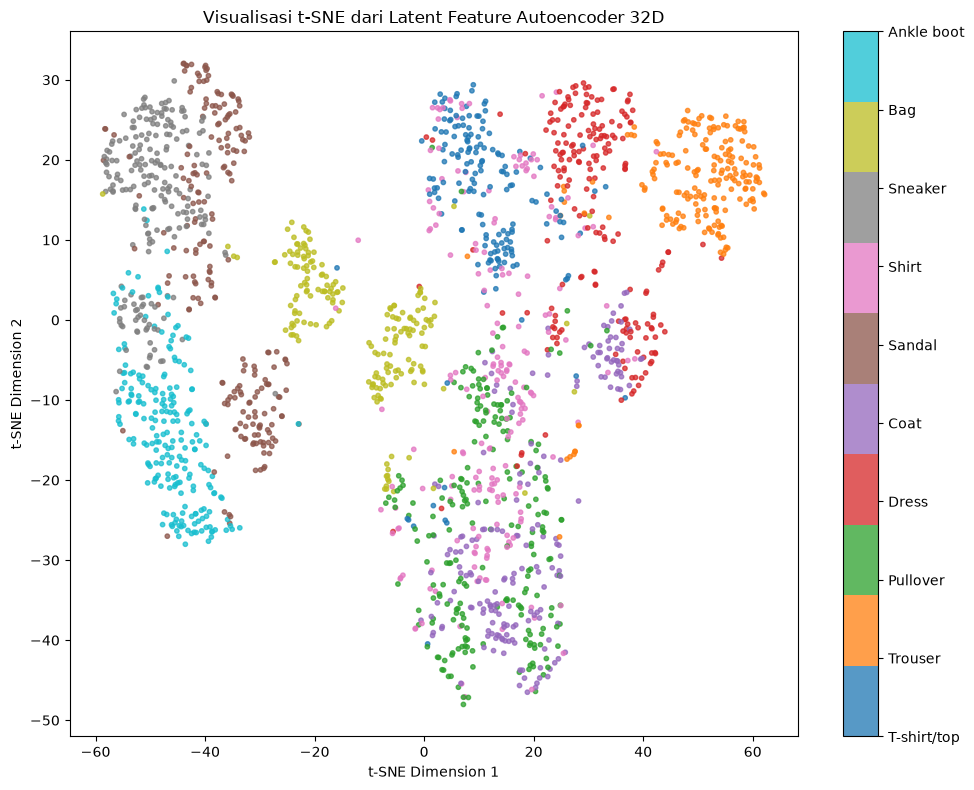

Gambar disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\tsne_autoencoder_32d.png


In [9]:
def plot_tsne(tsne_result, labels, class_names, title, output_file):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, s=10, alpha=0.75, cmap="tab10")
    cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
    cbar.ax.set_yticklabels(class_names)
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    output_path = FIGURES_DIR / output_file
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gambar disimpan ke:", output_path)

plot_tsne(tsne_raw, y_labels, class_names, "Visualisasi t-SNE dari Raw Pixel FashionMNIST", "tsne_raw_pixel.png")
plot_tsne(tsne_pca, y_labels, class_names, "Visualisasi t-SNE dari Fitur PCA 32D", "tsne_pca_32d.png")
plot_tsne(tsne_autoencoder, y_labels, class_names, "Visualisasi t-SNE dari Latent Feature Autoencoder 32D", "tsne_autoencoder_32d.png")

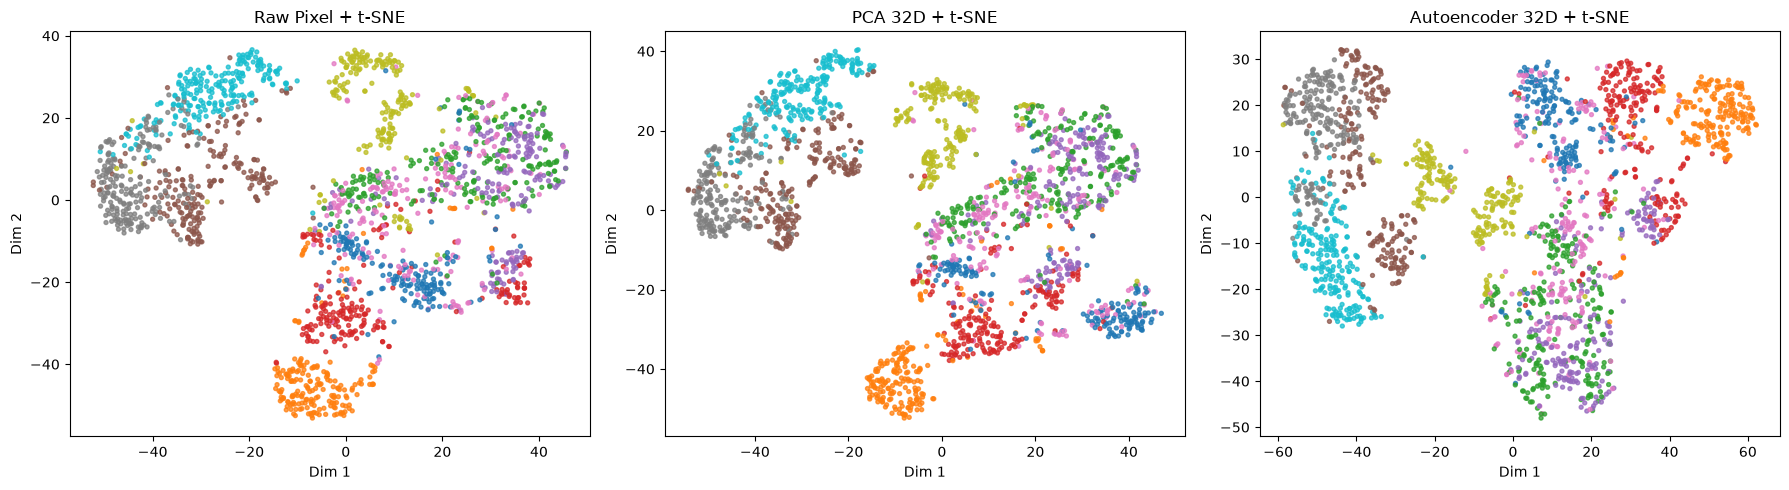

Gambar perbandingan t-SNE disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\tsne_comparison_all_methods.png


In [10]:
plt.figure(figsize=(18, 5))
plots = [(tsne_raw, "Raw Pixel + t-SNE"), (tsne_pca, "PCA 32D + t-SNE"), (tsne_autoencoder, "Autoencoder 32D + t-SNE")]
for i, (result, title) in enumerate(plots):
    plt.subplot(1, 3, i + 1)
    plt.scatter(result[:, 0], result[:, 1], c=y_labels, s=8, alpha=0.75, cmap="tab10")
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
plt.tight_layout()
combined_path = FIGURES_DIR / "tsne_comparison_all_methods.png"
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
print("Gambar perbandingan t-SNE disimpan ke:", combined_path)

In [11]:
pca_results_path = RESULTS_DIR / "pca_results.csv"
autoencoder_results_path = RESULTS_DIR / "autoencoder_results.csv"
comparison_rows = []
if pca_results_path.exists():
    comparison_rows.append(pd.read_csv(pca_results_path))
if autoencoder_results_path.exists():
    comparison_rows.append(pd.read_csv(autoencoder_results_path))
if comparison_rows:
    reduction_comparison = pd.concat(comparison_rows, ignore_index=True, sort=False)
    comparison_path = RESULTS_DIR / "reduction_comparison.csv"
    reduction_comparison.to_csv(comparison_path, index=False)
    display(reduction_comparison)
    print("Perbandingan reduksi dimensi disimpan ke:", comparison_path)

,method,input_dim,latent_dim,train_size,test_size,explained_variance_ratio,reconstruction_mse,processing_time_seconds,epochs,batch_size,learning_rate,training_time_seconds
0,PCA,784,32,10000,2000,0.826648,0.015455,0.164578,NaN,NaN,NaN,NaN
1,Autoencoder,784,32,60000,2000,NaN,0.010139,NaN,20.0,128.0,0.001,164.42071


Perbandingan reduksi dimensi disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\reduction_comparison.csv
